In [ ]:
from google.colab import files
uploaded = files.upload()
import pandas as pd
df = pd.read_excel('StdizedMerged63.xlsx')
print(df.head())

# Summary statistics
print(df[['Attack Type', 'Devices Affected']].describe())

# Attack vector frequency
attack_counts = df['Attack Type'].value_counts()
print(f"Top attack vectors:\n{attack_counts.head(3)}")  # [6]

# Convert timestamp column
df['Time'] = pd.to_datetime(df['IAT'])

# Hourly attack peaks
hourly_attacks = df.groupby(df['Time'].dt.hour).size()
print(f"Peak attack hours:\n{hourly_attacks.idxmax()}")  # [4][5]

# Monthly trends
monthly_trends = df.groupby(df['Time'].dt.month_name()).size()

import matplotlib.pyplot as plt

# Hourly attack pattern
hourly_attacks.plot(kind='line', title='Hourly Attack Frequency')
plt.xlabel('Hour of Day')
plt.ylabel('Attack Count')  # [4][7]

# Seasonal trends
monthly_trends.plot(kind='bar', title='Monthly Attack Distribution')

# Generate automated summary
summary = f"""
Cybersecurity Threat Report ({pd.IAT.now().strftime('%Y-%m-%d')})
- Total attacks: {len(df)}
- Top attack vector: {attack_counts.index[0]} ({attack_counts[0]} cases)
- Peak attack hour: {hourly_attacks.idxmax()}:00 ({hourly_attacks.max()} attacks)
"""
print(summary)

Saving StdizedMerged63.xlsx to StdizedMerged63 (2).xlsx
   Header_Length  Protocol Type          Rate  fin_flag_number  \
0           7.76             17  49096.380000              0.0   
1           7.92             17  17895.315300              0.0   
2           0.00              1  41169.061641              0.0   
3          20.00              6  16675.163996              0.0   
4          20.00              6  29516.565799              0.0   

   syn_flag_number  rst_flag_number  psh_flag_number  ack_flag_number  \
0              0.0              0.0         0.000000          0.00000   
1              0.0              0.0         0.000000          0.00000   
2              0.0              0.0         0.000000          0.00000   
3              0.0              0.0         3.253911          2.73392   
4              0.0              0.0         0.000000          0.00000   

   ack_count  syn_count  ...  SSH  TCP   UDP  Tot sum  Min  Max   AVG  \
0   0.000000        0.0  ...  0.0  

KeyError: "None of [Index(['Attack Type', 'Devices Affected'], dtype='object')] are in the [columns]"

Summary Statistics for Attack Patterns

In [ ]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
#drive.mount('/content/drive')

# Access and read Excel file from Drive
file_path = '/content/drive/My Drive/StdizedMerged63.xlsx'
df = pd.read_excel(file_path)
print(df.head())

# Summary statistics for impacted devices
print("Impacted Devices Statistics:")
print(df['Rate'].describe())

# Frequency of Protocol Types (attack types)
protocol_counts = df['Protocol Type'].value_counts()
print("Frequency of Protocol Types:")
print(protocol_counts)

# Flag analysis
flag_columns = ['fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number']
flag_summary = df[flag_columns].sum()
print("Flag Analysis Summary:")
print(flag_summary)


   Header_Length  Protocol Type          Rate  fin_flag_number  \
0           7.76             17  49096.380000              0.0   
1           7.92             17  17895.315300              0.0   
2           0.00              1  41169.061641              0.0   
3          20.00              6  16675.163996              0.0   
4          20.00              6  29516.565799              0.0   

   syn_flag_number  rst_flag_number  psh_flag_number  ack_flag_number  \
0              0.0              0.0         0.000000          0.00000   
1              0.0              0.0         0.000000          0.00000   
2              0.0              0.0         0.000000          0.00000   
3              0.0              0.0         3.253911          2.73392   
4              0.0              0.0         0.000000          0.00000   

   ack_count  syn_count  ...  SSH  TCP   UDP  Tot sum  Min  Max   AVG  \
0   0.000000        0.0  ...  0.0  0.0  0.97     6030   60   70  60.3   
1   0.000000      

In [ ]:
from google.colab import drive
import pandas as pd

# Access and read Excel file from Drive
file_path = '/content/drive/My Drive/StdizedMerged63.xlsx'
df = pd.read_excel(file_path)
print(df.head())

# Convert timestamp to datetime format
df['IAT'] = pd.to_datetime(df['IAT'])

# Group by hour
hourly_attacks = df.groupby(df['IAT'].dt.hour).size()
hourly_attacks.plot(kind='line', title='Hourly Attack Frequency')
plt.xlabel('Hour of Day')
plt.ylabel('Attack Count')
plt.grid()
plt.show()


In [ ]:
# Import necessary libraries
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Excel file into a DataFrame
file_path = '/content/drive/My Drive/StdizedMerged63.xlsx'
df = pd.read_excel('StdizedMerged63.xlsx')
print(df.head())

# Clean column names (strip spaces and make lowercase)
df.columns = df.columns.str.strip().str.lower()

# Display the exact column names for debugging
print("\n🔹 Column Names in Dataset:", df.columns.tolist())

# Display the first few rows to check data structure
print("\n🔹 First 5 rows of the dataset:")
display(df.head())

# Check for missing values
print("\n🔹 Missing Values Count:")
print(df.isnull().sum())

# Display summary statistics of numerical columns
print("\n🔹 Summary Statistics:")
display(df.describe())

# Check data types
print("\n🔹 Data types:")
print(df.dtypes)

# ---- Identify Relevant Column Names (Excluding Attack Type & Device Type) ----
label = None  # Label column (instead of attack type)
for col in df.columns:
    if "Label" in col:
        label = col  # Use label instead of attack type

# Debugging Output
if label:
    print(f"\n✅ Identified 'Label' Column: {label}")
else:
    print("\n❌ Error: 'Label' column not found in dataset.")

# ---- Label Frequency ----
if label:
    label_counts = df[label].value_counts()
    print(f"\n🔹 Top label categories:\n{label_counts.head(3)}")

# ---- Label Distribution ----
if label:
    plt.figure(figsize=(10, 6))
    df[label].value_counts().plot(kind='bar', color='purple', alpha=0.7)
    plt.title('Frequency of Labels')
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

# ---- Using .iat[] for Specific Data Extraction ----
print("\n🔹 First label:", df.iat[0, df.columns.get_loc(label)] if label else "N/A")

# ---- Correlation Heatmap (Excluding Attack Type & Device Type) ----
correlation_matrix = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# ---- Automated Summary Report ----
summary = f"""
Cybersecurity Threat Report ({pd.Timestamp.now().strftime('%Y-%m-%d')})
- Total records: {len(df)}
- Top label category: {df[label].value_counts().idxmax()} ({df[label].value_counts().max()} cases) if label else "N/A"
"""
print(summary)

# Example data (replace with your actual data)
attack_counts = df['Label'].value_counts()

# Plot the frequency of attack types
plt.figure(figsize=(14, 8))  # Increase figure size
attack_counts.plot(kind='bar', color='skyblue', alpha=0.9)

# Customize the chart
plt.title('Frequency of Attack Types', fontsize=16, fontweight='bold')
plt.xlabel('Attack Type', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotate labels and align them to the right
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal gridlines

# Show the plot
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()



   Header_Length  Protocol Type          Rate  fin_flag_number  \
0           7.76             17  49096.380000              0.0   
1           7.92             17  17895.315300              0.0   
2           0.00              1  41169.061641              0.0   
3          20.00              6  16675.163996              0.0   
4          20.00              6  29516.565799              0.0   

   syn_flag_number  rst_flag_number  psh_flag_number  ack_flag_number  \
0              0.0              0.0              0.0              0.0   
1              0.0              0.0              0.0              0.0   
2              0.0              0.0              0.0              0.0   
3              0.0              0.0              1.0              1.0   
4              0.0              0.0              0.0              0.0   

   ack_count  syn_count  ...  0.058373  HTTPS.1  0.002619  DNS.1  0.000011  \
0          0          0  ...  0.218591      0.0  0.022043    0.0  0.000642   
1       

,header_length,protocol type,rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ack_count,syn_count,...,NaN,https.1,NaN,dns.1,NaN,telnet.1,NaN,smtp.1,NaN,ssh.1
0,7.76,17,49096.380000,0.0,0.0,0.0,0.0,0.0,0,0,...,0.218591,0.0,0.022043,0.0,0.000642,0.0,0.000961,0.0,0.007423,0.0
1,7.92,17,17895.315300,0.0,0.0,0.0,0.0,0.0,0,0,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2,0.00,1,41169.061641,0.0,0.0,0.0,0.0,0.0,0,0,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
3,20.00,6,16675.163996,0.0,0.0,0.0,1.0,1.0,100,0,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
4,20.00,6,29516.565799,0.0,0.0,0.0,0.0,0.0,0,0,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0



🔹 Missing Values Count:
header_length           0
protocol type           0
rate                    0
fin_flag_number         0
syn_flag_number         0
                    ...  
telnet.1                0
NaN                428160
smtp.1                  0
NaN                428160
ssh.1                   0
Length: 62, dtype: int64

🔹 Summary Statistics:


,header_length,protocol type,rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ack_count,syn_count,...,NaN,https.1,NaN,dns.1,NaN,telnet.1,NaN,smtp.1,NaN,ssh.1
count,428161.000000,428161.000000,4.281610e+05,428161.00000,428161.000000,428161.000000,428161.000000,428161.000000,428161.000000,428161.000000,...,1.000000,428161.000000,1.000000,428161.000000,1.000000,428161.000000,1.000000,428161.000000,1.000000,428161.000000
mean,13.737697,9.097188,inf,0.08666,0.206395,0.092482,0.094711,0.130992,9.947510,20.395242,...,0.218591,0.228730,0.022043,0.111540,0.000642,0.017349,0.000961,0.012428,0.007423,0.028098
std,8.735455,9.115007,NaN,0.27898,0.399434,0.282737,0.278227,0.317893,28.134731,39.903610,...,NaN,0.941654,NaN,0.987119,NaN,0.999700,NaN,0.999847,NaN,0.999210
min,0.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.218591,-0.221294,0.022043,0.000000,0.000642,0.000000,0.000961,0.000000,0.007423,0.000000
25%,8.000000,6.000000,1.134700e+04,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.218591,0.000000,0.022043,0.000000,0.000642,0.000000,0.000961,0.000000,0.007423,0.000000
50%,20.000000,6.000000,2.454675e+04,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.218591,0.000000,0.022043,0.000000,0.000642,0.000000,0.000961,0.000000,0.007423,0.000000
75%,20.000000,17.000000,3.787866e+04,0.00000,0.010000,0.000000,0.000000,0.010000,1.000000,1.000000,...,0.218591,0.000000,0.022043,0.000000,0.000642,0.000000,0.000961,0.000000,0.007423,0.000000
max,60.000000,47.000000,inf,1.00000,1.000000,1.000000,1.000000,1.000000,100.000000,100.000000,...,0.218591,4.307702,0.022043,45.248040,0.000642,311.708513,0.000961,520.066486,0.007423,134.680509



🔹 Data types:
header_length      float64
protocol type        int64
rate               float64
fin_flag_number    float64
syn_flag_number    float64
                    ...   
telnet.1           float64
NaN                float64
smtp.1             float64
NaN                float64
ssh.1              float64
Length: 62, dtype: object


TypeError: argument of type 'float' is not iterable

Saving StdizedMerged63.xlsx to StdizedMerged63 (3).xlsx
   Header_Length  Protocol Type          Rate  fin_flag_number  \
0           7.76             17  49096.380000              0.0   
1           7.92             17  17895.315300              0.0   
2           0.00              1  41169.061641              0.0   
3          20.00              6  16675.163996              0.0   
4          20.00              6  29516.565799              0.0   

   syn_flag_number  rst_flag_number  psh_flag_number  ack_flag_number  \
0              0.0              0.0         0.000000          0.00000   
1              0.0              0.0         0.000000          0.00000   
2              0.0              0.0         0.000000          0.00000   
3              0.0              0.0         3.253911          2.73392   
4              0.0              0.0         0.000000          0.00000   

   ack_count  syn_count  ...  SSH  TCP   UDP  Tot sum  Min  Max   AVG  \
0   0.000000        0.0  ...  0.0  

,header_length,protocol type,rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ack_count,syn_count,...,ssh,tcp,udp,tot sum,min,max,avg,std,iat,label
0,7.76,17,49096.380000,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.0,...,0.0,0.0,0.97,6030,60,70,60.3,1.714466,0.000021,DOS-UDP_FLOOD
1,7.92,17,17895.315300,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.0,...,0.0,0.0,0.99,6000,60,60,60.0,0.000000,0.000056,DDOS-UDP_FLOOD
2,0.00,1,41169.061641,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.0,...,0.0,0.0,0.00,6000,60,60,60.0,0.000000,0.000024,DDOS-ICMP_FLOOD
3,20.00,6,16675.163996,0.0,0.0,0.0,3.253911,2.73392,3.200763,0.0,...,0.0,1.0,0.00,6000,60,60,60.0,0.000000,0.000060,DDOS-PSHACK_FLOOD
4,20.00,6,29516.565799,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.0,...,0.0,1.0,0.00,6000,60,60,60.0,0.000000,0.000034,DOS-TCP_FLOOD



🔹 Missing Values Count:
header_length      0
protocol type      0
rate               0
fin_flag_number    0
syn_flag_number    0
rst_flag_number    0
psh_flag_number    0
ack_flag_number    0
ack_count          0
syn_count          0
fin_count          0
rst_count          0
http               0
https              0
dns                0
telnet             0
smtp               0
ssh                0
tcp                0
udp                0
tot sum            0
min                0
max                0
avg                0
std                0
iat                0
label              0
dtype: int64

🔹 Summary Statistics:


,header_length,protocol type,rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ack_count,syn_count,...,smtp,ssh,tcp,udp,tot sum,min,max,avg,std,iat
count,428161.000000,428161.000000,4.281610e+05,428161.000000,428161.000000,428161.000000,428161.000000,428161.000000,428161.000000,428161.000000,...,428161.000000,428161.000000,428161.000000,428161.000000,428161.000000,428161.000000,428161.000000,428161.000000,428161.000000,428161.000000
mean,13.737697,9.097188,inf,0.275412,0.381998,0.286228,0.281647,0.306049,0.262564,0.377841,...,0.012428,0.028098,0.574716,0.216769,10976.881928,80.009737,225.574550,131.979733,41.958080,0.013008
std,8.735455,9.115007,NaN,0.915778,0.810397,0.908025,0.908226,0.883408,0.915548,0.814933,...,0.999847,0.999210,0.484785,0.400577,16904.824627,107.935486,593.054785,230.944523,183.709834,8.021702
min,0.000000,0.000000,0.000000e+00,-0.274777,-0.491663,-0.291707,-0.304444,-0.380516,-0.318024,-0.486052,...,0.000000,0.000000,0.000000,0.000000,60.000000,42.000000,54.000000,47.400000,0.000000,0.000000
25%,8.000000,6.000000,1.134700e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,6000.000000,60.000000,60.000000,60.000000,0.000000,0.000026
50%,20.000000,6.000000,2.454675e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.990000,0.000000,6000.000000,60.000000,60.000000,60.000000,0.000000,0.000039
75%,20.000000,17.000000,3.787866e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.020000,6011.000000,60.000000,74.000000,60.260000,0.900000,0.000081
max,60.000000,47.000000,inf,3.273943,1.986883,3.209863,3.253911,2.733920,3.200763,1.994926,...,520.066486,134.680509,1.000000,1.000000,235549.000000,5858.000000,31922.000000,6011.800000,9730.179418,5248.800000



🔹 Data types:
header_length      float64
protocol type        int64
rate               float64
fin_flag_number    float64
syn_flag_number    float64
rst_flag_number    float64
psh_flag_number    float64
ack_flag_number    float64
ack_count          float64
syn_count          float64
fin_count          float64
rst_count          float64
http               float64
https              float64
dns                float64
telnet             float64
smtp               float64
ssh                float64
tcp                float64
udp                float64
tot sum              int64
min                  int64
max                  int64
avg                float64
std                float64
iat                float64
label               object
dtype: object

✅ Identified 'Label' Column: label

🔹 Top label categories:
label
DDOS-ICMP_FLOOD    65637
DDOS-UDP_FLOOD     49192
DDOS-TCP_FLOOD     40820
Name: count, dtype: int64


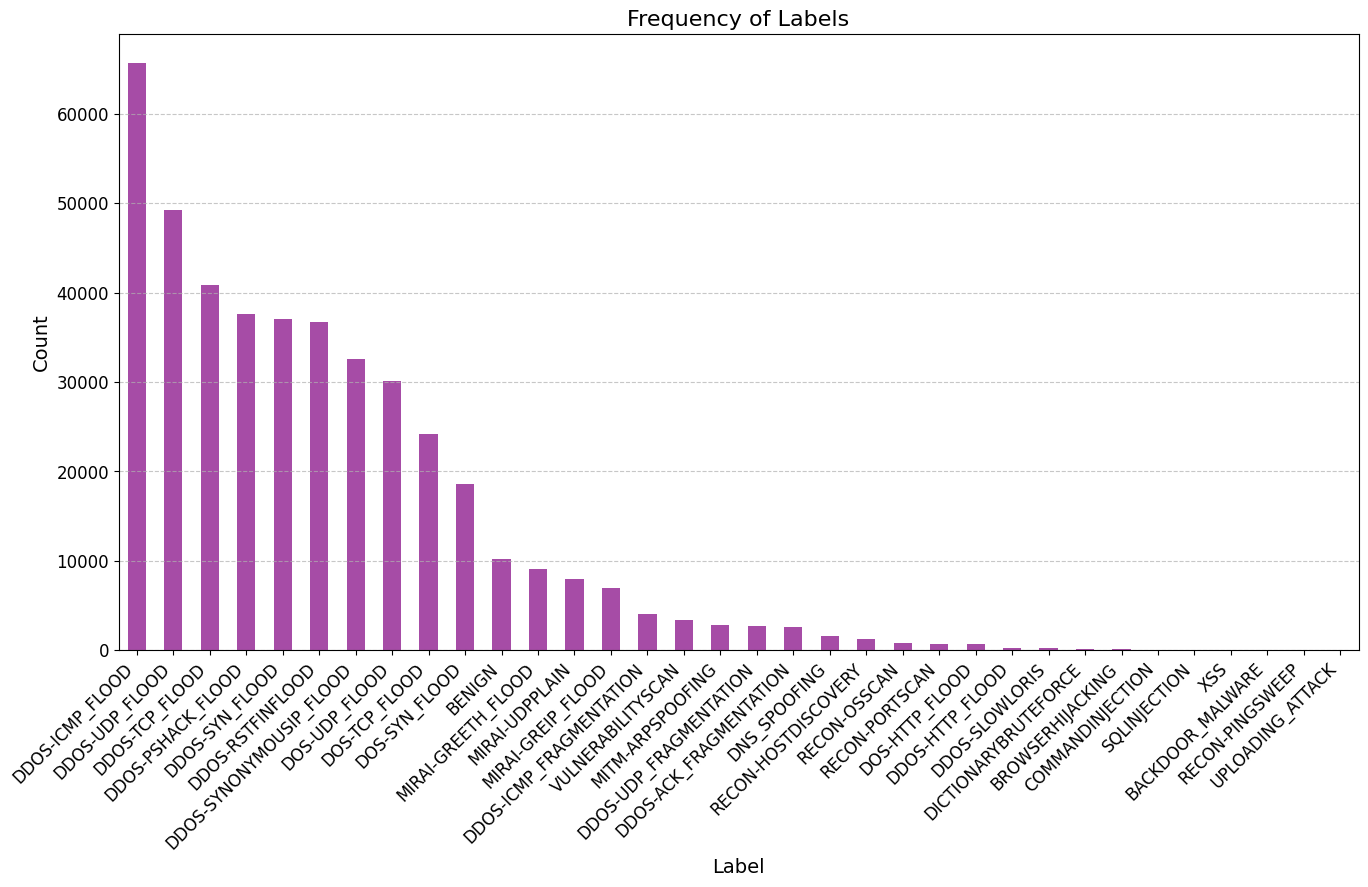


🔹 First label: DOS-UDP_FLOOD


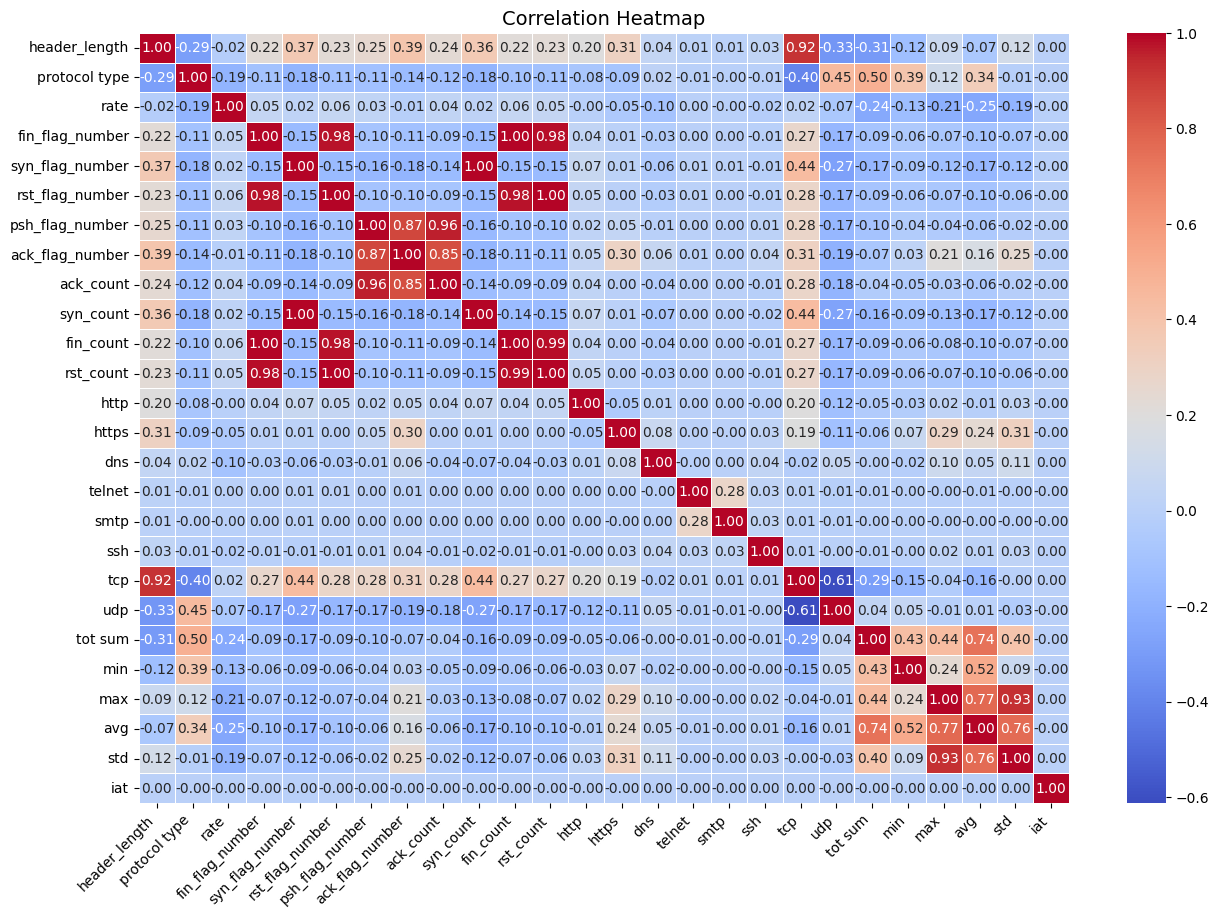


Cybersecurity Threat Report (2025-04-03)
- Total records: 428161
- Top label category: DDOS-ICMP_FLOOD (65637 cases) if label else "N/A"



In [ ]:
# Import necessary libraries
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Excel file into a DataFrame
uploaded = files.upload()  # Allows manual file upload
file_name = list(uploaded.keys())[0]  # Gets the uploaded file name
df = pd.read_excel(file_name)  # Read the uploaded file
print(df.head())

# Clean column names (strip spaces and make lowercase)
df.columns = df.columns.str.strip().str.lower()

# Display the exact column names for debugging
print("\n🔹 Column Names in Dataset:", df.columns.tolist())

# Display the first few rows to check data structure
print("\n🔹 First 5 rows of the dataset:")
display(df.head())

# Check for missing values
print("\n🔹 Missing Values Count:")
print(df.isnull().sum())

# Display summary statistics of numerical columns
print("\n🔹 Summary Statistics:")
display(df.describe())

# Check data types
print("\n🔹 Data types:")
print(df.dtypes)

# ---- Identify Relevant Column Names (Excluding Attack Type & Device Type) ----
label = None  # Label column (instead of attack type)
for col in df.columns:
    if "label" in col:
        label = col  # Use label instead of attack type

# Debugging Output
if label:
    print(f"\n✅ Identified 'Label' Column: {label}")
else:
    print("\n❌ Error: 'Label' column not found in dataset.")

# ---- Label Frequency ----
if label:
    label_counts = df[label].value_counts()
    print(f"\n🔹 Top label categories:\n{label_counts.head(3)}")

# ---- Improved Label Frequency Distribution ----
if label:
    plt.figure(figsize=(16, 8))  # Increase figure size
    ax = df[label].value_counts().plot(kind='bar', color='purple', alpha=0.7)

    plt.title('Frequency of Labels', fontsize=16)  # Larger title font
    plt.xlabel('Label', fontsize=14)  # Larger x-axis label font
    plt.ylabel('Count', fontsize=14)  # Larger y-axis label font

    plt.xticks(rotation=45, ha='right', fontsize=12)  # Improve x-axis label readability
    plt.yticks(fontsize=12)  # Increase y-axis tick font size
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add grid for better readability

    plt.show()

# ---- Using .iat[] for Specific Data Extraction ----
print("\n🔹 First label:", df.iat[0, df.columns.get_loc(label)] if label else "N/A")

# ---- Improved Correlation Heatmap ----
correlation_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(15, 10))  # Increase figure size for better readability
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.yticks(rotation=0)  # Keep y-axis labels horizontal
plt.title('Correlation Heatmap', fontsize=14)  # Increase title font size
plt.show()

# ---- Automated Summary Report ----
summary = f"""
Cybersecurity Threat Report ({pd.Timestamp.now().strftime('%Y-%m-%d')})
- Total records: {len(df)}
- Top label category: {df[label].value_counts().idxmax()} ({df[label].value_counts().max()} cases) if label else "N/A"
"""
print(summary)


Mounted at /content/drive


Saving StdizedMerged63.xlsx to StdizedMerged63.xlsx
Linear Regression MSE: 18.1249, R-squared: 0.4924
Random Forest MSE: 10.8821, R-squared: 0.6953
Gradient Boosting MSE: 11.2075, R-squared: 0.6861


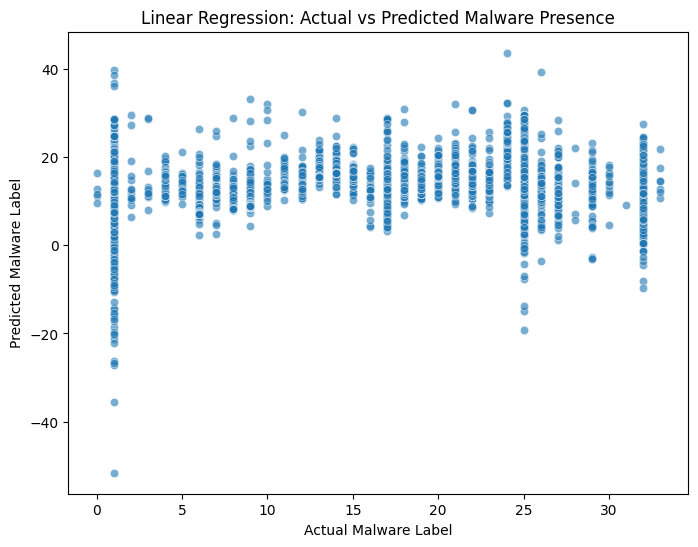

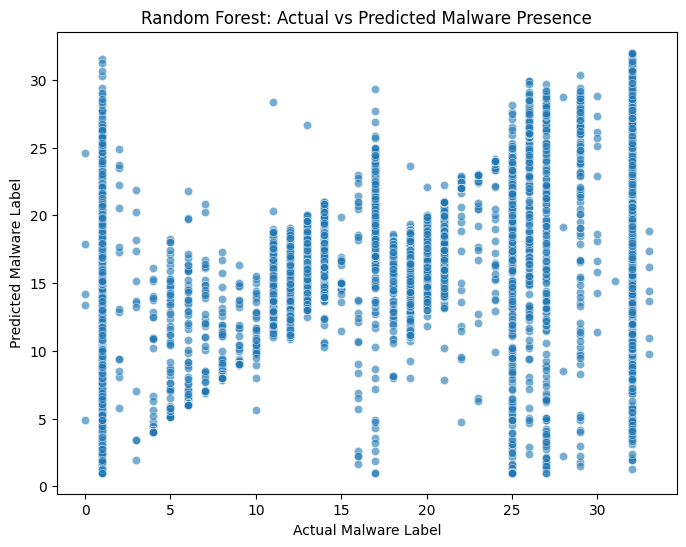

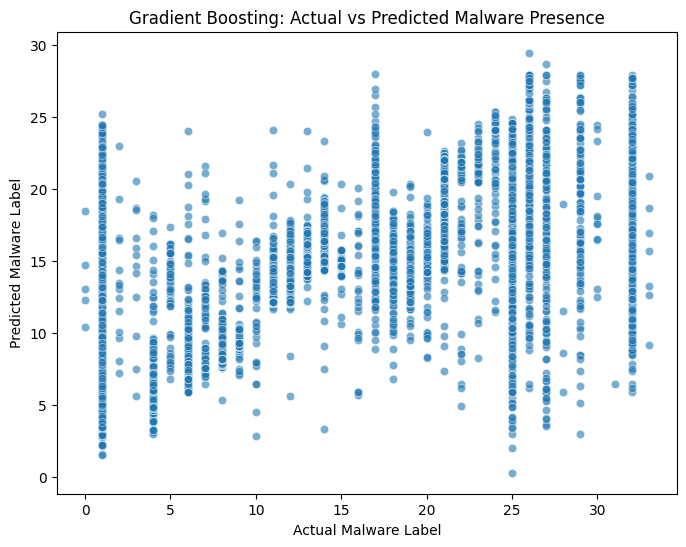

Random Forest Feature Importances:
            Feature  Importance
12              udp    0.189222
11              tcp    0.151706
13          tot sum    0.121776
17              std    0.117328
18              iat    0.110788
0   psh_flag_number    0.064375
3         fin_count    0.059406
15              max    0.042381
16              avg    0.031661
2         syn_count    0.029136
6             https    0.027962
1   ack_flag_number    0.018294
5              http    0.012279
14              min    0.011949
7               dns    0.006465
4         rst_count    0.003934
10              ssh    0.001274
9              smtp    0.000031
8            telnet    0.000031
Gradient Boosting Feature Importances:
            Feature  Importance
12              udp    0.241002
11              tcp    0.200515
13          tot sum    0.121856
17              std    0.099576
3         fin_count    0.063732
16              avg    0.055816
0   psh_flag_number    0.053672
15              max    0.04852

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from scipy import stats

# Mount Google Drive
drive.mount('/content/drive')

# Load dataset
from google.colab import files

uploaded = files.upload()  # Allows manual file upload
file_name = list(uploaded.keys())[0]  # Gets the uploaded file name
df = pd.read_excel(file_name)  # Read the uploaded file

# Data Cleaning: Strip spaces and lowercase column names
df.columns = df.columns.str.strip().str.lower()

# Convert the 'label' column (which has categorical values) into numeric labels
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])  # Dependent variable (label)

# Define Dependent and Independent Variables
dependent_var = 'label'  # Assuming 'Label' indicates malware presence
independent_vars = ['psh_flag_number', 'ack_flag_number', 'syn_count', 'fin_count', 'rst_count',
                     'http', 'https', 'dns', 'telnet', 'smtp', 'ssh', 'tcp', 'udp',
                     'tot sum', 'min', 'max', 'avg', 'std', 'iat']  # Features relevant to network behavior

# Filter only numeric columns & drop missing values
df = df[independent_vars + [dependent_var]].dropna()

# Split dataset into training and testing sets
X = df[independent_vars]
y = df[dependent_var]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Step 1: Feature Engineering ---
# Standardizing (Scaling) the Features for better model performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Polynomial Features (degree=2 for quadratic features)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_scaled)

# --- Step 2: Train Linear Regression Model ---
# Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on test data
lr_y_pred = lr_model.predict(X_test)

# Evaluate Model
lr_mse = mean_squared_error(y_test, lr_y_pred)
lr_r2 = r2_score(y_test, lr_y_pred)

# --- Step 3: Try More Complex Models ---

# Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)

# Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_y_pred = gb_model.predict(X_test)

# --- Step 4: Outlier Handling ---
# Using Z-scores to remove outliers (values beyond 3 standard deviations)
z_scores = np.abs(stats.zscore(X_scaled))
X_no_outliers = X_scaled[(z_scores < 3).all(axis=1)]
y_no_outliers = y[(z_scores < 3).all(axis=1)]

# Split the dataset again after removing outliers
X_train_no_outliers, X_test_no_outliers, y_train_no_outliers, y_test_no_outliers = train_test_split(
    X_no_outliers, y_no_outliers, test_size=0.2, random_state=42
)

# --- Step 5: Evaluate All Models ---
# Random Forest Evaluation
rf_mse = mean_squared_error(y_test, rf_y_pred)
rf_r2 = r2_score(y_test, rf_y_pred)

# Gradient Boosting Evaluation
gb_mse = mean_squared_error(y_test, gb_y_pred)
gb_r2 = r2_score(y_test, gb_y_pred)

# --- Step 6: Print Results ---
print(f'Linear Regression MSE: {lr_mse:.4f}, R-squared: {lr_r2:.4f}')
print(f'Random Forest MSE: {rf_mse:.4f}, R-squared: {rf_r2:.4f}')
print(f'Gradient Boosting MSE: {gb_mse:.4f}, R-squared: {gb_r2:.4f}')

# --- Step 7: Plot Results ---
# Plotting Actual vs Predicted for all models

# Linear Regression Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=lr_y_pred, alpha=0.6)
plt.xlabel("Actual Malware Label")
plt.ylabel("Predicted Malware Label")
plt.title("Linear Regression: Actual vs Predicted Malware Presence")
plt.show()

# Random Forest Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=rf_y_pred, alpha=0.6)
plt.xlabel("Actual Malware Label")
plt.ylabel("Predicted Malware Label")
plt.title("Random Forest: Actual vs Predicted Malware Presence")
plt.show()

# Gradient Boosting Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=gb_y_pred, alpha=0.6)
plt.xlabel("Actual Malware Label")
plt.ylabel("Predicted Malware Label")
plt.title("Gradient Boosting: Actual vs Predicted Malware Presence")
plt.show()

# --- Step 8: Coefficients for Random Forest and Gradient Boosting ---
# Random Forest Feature Importances
rf_feature_importances = pd.DataFrame({
    'Feature': independent_vars,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Random Forest Feature Importances:")
print(rf_feature_importances)

# Gradient Boosting Feature Importances
gb_feature_importances = pd.DataFrame({
    'Feature': independent_vars,
    'Importance': gb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Gradient Boosting Feature Importances:")
print(gb_feature_importances)





APPLY ML MODELS

Prepare the Dataset

In [ ]:
from google.colab import drive
import pandas as pd

# Load dataset
from google.colab import files

# Define features (X) and target variable (y)
X = df.drop(columns=['Label'])  # Assuming 'Label' is the target column
y = df['Label']

Tahn

Dataset loaded successfully!

Data Preprocessing Steps:

Checking for infinity or NaN values in features...
Columns with NaN values (caused by infinities):
Rate    10
dtype: int64
Infinity and NaN values handled successfully!


Original Class Distribution:
Label_encoded
6     65637
14    49192
13    40820
8     37600
12    37033
9     36744
11    32539
21    30141
20    24161
19    18595
1     10181
22     9107
24     7990
23     6902
7      4085
32     3372
25     2848
15     2695
4      2619
17     1590
26     1231
27      850
29      726
18      643
5       254
10      205
16      116
2        74
3        56
30       47
33       42
0        34
28       22
31       10
Name: count, dtype: int64

Resampled Class Distribution:
Label_encoded
21    65637
14    65637
6     65637
8     65637
20    65637
11    65637
13    65637
15    65637
32    65637
23    65637
19    65637
24    65637
22    65637
9     65637
12    65637
17    65637
1     65637
4     65637
7     65637
29    65637
25    6563

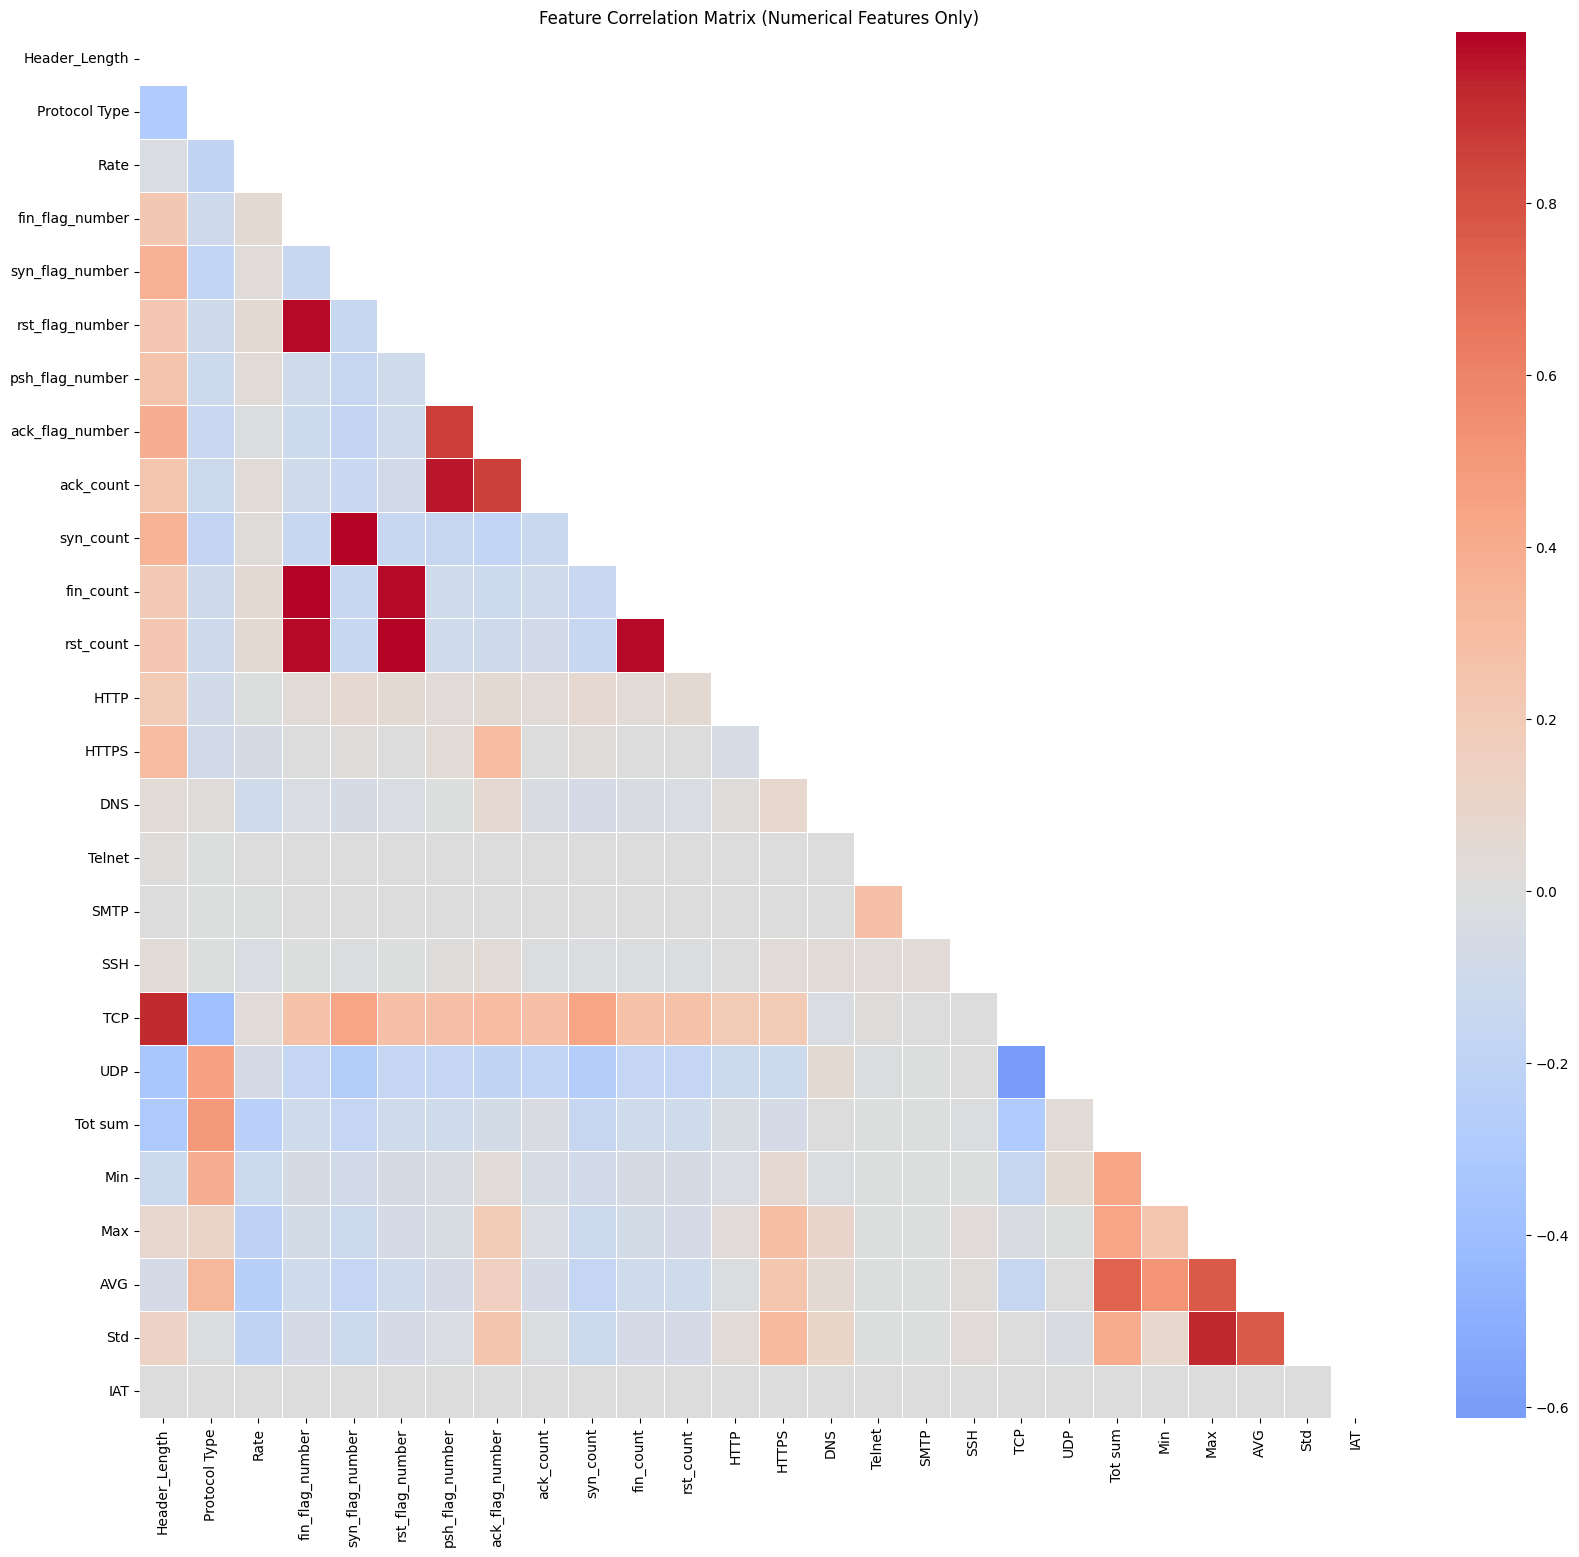


Removed 7 highly correlated features: ['rst_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'TCP', 'Std']


ValueError: Found input variables with inconsistent numbers of samples: [428161, 2231658]

In [ ]:
# Install required libraries (if not already installed)
#!pip install openpyxl scikit-learn imbalanced-learn seaborn xgboost

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                            classification_report, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif

# Mount Google Drive
#drive.mount('/content/drive')

# Load dataset with error handling
try:
    file_path = '/content/drive/My Drive/StdizedMerged63.xlsx'
    df = pd.read_excel(file_path, engine='openpyxl')
    print("Dataset loaded successfully!\n")
except Exception as e:
    print(f"Error loading file: {e}")
    raise

# Data preprocessing
print("Data Preprocessing Steps:")
# 1. Encode labels
le = LabelEncoder()
df['Label_encoded'] = le.fit_transform(df['Label'])

# 2. Separate features and target
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_features.remove('Label_encoded')  # Remove encoded target from features
X = df[numerical_features]
y = df['Label_encoded']

# 3. Handle infinity or large values in X
print("\nChecking for infinity or NaN values in features...")
X_cleaned = X.replace([np.inf, -np.inf], np.nan)  # Replace infinities with NaN

# Check which columns have NaN values (caused by infinities or missing data)
infinity_check = X_cleaned.isnull().sum()
print("Columns with NaN values (caused by infinities):")
print(infinity_check[infinity_check > 0])

# Replace NaN values with column medians
for col in X_cleaned.columns:
    X_cleaned[col] = X_cleaned[col].fillna(X_cleaned[col].median())

print("Infinity and NaN values handled successfully!\n")

# Handle Class Imbalance using SMOTE after cleaning the data
print("\nOriginal Class Distribution:")
print(pd.Series(y).value_counts())
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_cleaned, y)
print("\nResampled Class Distribution:")
print(pd.Series(y_res).value_counts())

# Correlation analysis (numerical features only)
plt.figure(figsize=(20, 18))
corr_matrix = X_cleaned.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm',
            center=0, annot=False, linewidths=0.5)
plt.title("Feature Correlation Matrix (Numerical Features Only)")
plt.show()

# Feature selection based on correlations
# Remove highly correlated features (|correlation| > 0.9)
corr_matrix = X_cleaned.corr().abs()
upper = corr_matrix.where(np.triu(np.ones_like(corr_matrix, dtype=bool), k=1))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
X_filtered = X_cleaned.drop(columns=to_drop)
print(f"\nRemoved {len(to_drop)} highly correlated features: {to_drop}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_res,
    test_size=0.2,
    random_state=42,
    stratify=y_res
)

# Build optimized pipeline
model = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selector', SelectKBest(score_func=f_classif, k=20)),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ))
])

# Train model
model.fit(X_train, y_train)

# Evaluate model performance on the test set
y_pred = model.predict(X_test)
print("\nOptimized Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Feature importance visualization
feature_importances = model.named_steps['classifier'].feature_importances_
selected_features = X_filtered.columns[model.named_steps['feature_selector'].get_support()]
importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Top 20 Important Features for Attack Prediction")
plt.show()

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(25, 20))
disp.plot(ax=ax, xticks_rotation=90)
plt.title("Attack Type Classification Matrix")
plt.show()


✅ Confusion Matrix:
 [[   0    4    0 ...    0    1    0]
 [   0 1829    0 ...    0  144    0]
 [   0    4    0 ...    0    5    0]
 ...
 [   0    0    0 ...    0    1    0]
 [   0  217    0 ...    0  400    0]
 [   0    5    0 ...    0    2    0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



✅ Classification Report:
                          precision    recall  f1-score   support

       BACKDOOR_MALWARE       0.00      0.00      0.00         5
                 BENIGN       0.76      0.90      0.82      2035
       BROWSERHIJACKING       0.00      0.00      0.00        12
       COMMANDINJECTION       1.00      0.20      0.33        10
 DDOS-ACK_FRAGMENTATION       0.98      0.98      0.98       505
        DDOS-HTTP_FLOOD       0.93      0.61      0.73        61
        DDOS-ICMP_FLOOD       1.00      1.00      1.00     13140
DDOS-ICMP_FRAGMENTATION       0.99      0.98      0.99       881
      DDOS-PSHACK_FLOOD       1.00      1.00      1.00      7591
       DDOS-RSTFINFLOOD       1.00      1.00      1.00      7279
         DDOS-SLOWLORIS       0.70      0.83      0.76        47
DDOS-SYNONYMOUSIP_FLOOD       0.50      0.49      0.50      6525
         DDOS-SYN_FLOOD       0.48      0.51      0.49      7377
         DDOS-TCP_FLOOD       0.70      0.72      0.71      81

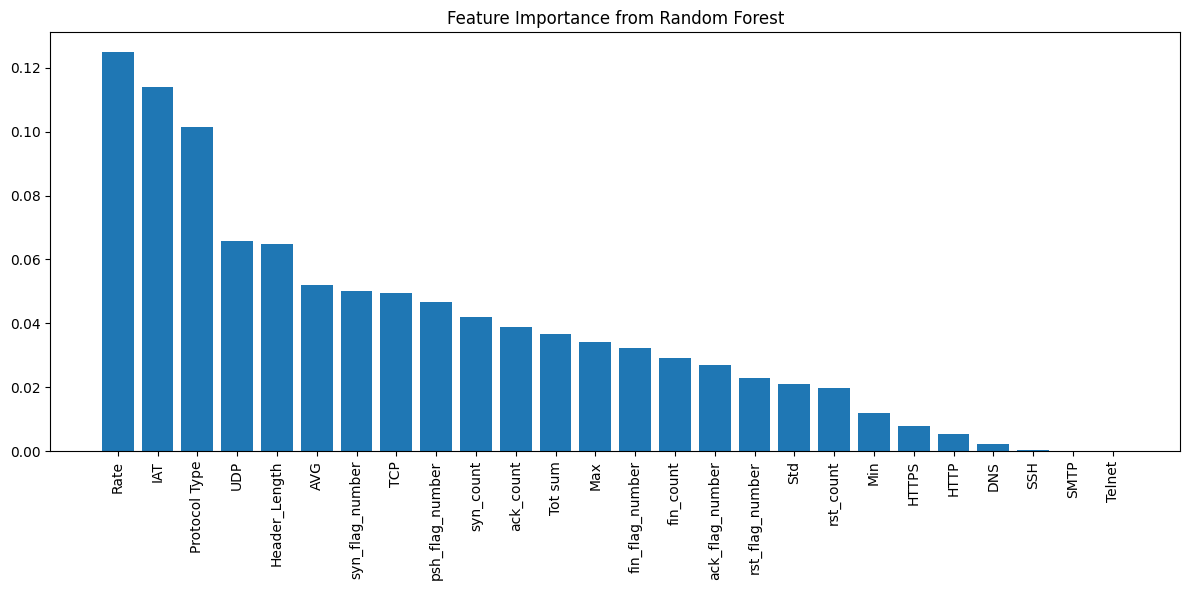

In [ ]:
# Step 1: Import libraries
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# Step 2: Load Excel file
df = pd.read_excel("StdizedMerged63.xlsx")

# Step 3: Define features (X) and target (y)
X = df.drop(columns=['Label'])  # Replace 'Label' if your target column has a different name
y = df['Label']

# Step 4: Clean the data (handle inf, -inf, NaN)
X = X.replace([float('inf'), float('-inf')], pd.NA)
X = X.dropna()  # You can also use X = X.fillna(0) instead
y = y.loc[X.index]  # Align target with cleaned features

# Step 5: Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Step 7: Make predictions
y_pred = rf_model.predict(X_test)

# Step 8: Evaluate model
print("✅ Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n✅ Classification Report:\n", classification_report(y_test, y_pred))
print("✅ Accuracy Score:", accuracy_score(y_test, y_pred))

# Step 9: Feature importance visualization
importances = rf_model.feature_importances_
features = X.columns
indices = importances.argsort()[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importance from Random Forest")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), features[indices], rotation=90)
plt.tight_layout()
plt.show()
